# House Price Estimation — Ames Housing Dataset
### Python Final Term Project — Summer 25-26 Semester
### Pathway: **Regression**

This notebook implements the full data-science workflow required by the
project brief, covering stages **DW-1 through DW-10**. Every section below
is labelled with the workflow stage it satisfies.

## 1. Problem Formulation  *(DW-1)*

**Decision / Question.** Given the physical, locational, and quality
attributes of a residential property in Ames, Iowa, can we predict its
final **sale price** (in USD)?

**Unit of analysis.** One residential property sale.

**Inputs.** 80+ property attributes describing lot, building style, quality
ratings, above-ground and basement living area, garage, and sale conditions.

**Target.** `SalePrice` — a continuous value in USD.

**What a useful result would mean.** A model that estimates a fair sale
price within a small percentage of the true value would help buyers,
sellers, and appraisers set realistic expectations and identify
under/overpriced listings. However, this is a *retrospective* model built
on 2006–2010 sales in one small US city; it cannot be used to forecast
future markets or to price homes outside Ames.

## 2. Data Provenance  *(DW-2)*

| Item              | Detail                                                                 |
|-------------------|------------------------------------------------------------------------|
| Source            | Dean De Cock (2011), *Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project*, Journal of Statistics Education, Vol. 19, No. 3. |
| Collection        | Assembled by the Ames City Assessor's Office; records of individual property sales in Ames, Iowa. |
| Time period       | 2006–2010                                                              |
| Records           | 2,930 property sales                                                   |
| Fields            | 82 explanatory variables + 1 target (`SalePrice`)                     |
| License           | Publicly released for academic use.                                    |
| Ethical concerns  | Records contain no personal identifiers about buyers or sellers. Neighbourhood-level features could encode socioeconomic patterns; we discuss this in the limitations section. |

## Setup — Imports, seed, paths

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths (relative to the project root; run the notebook from the project root)
DATA_RAW  = os.path.join("..", "data", "raw", "AmesHousing.csv")
FIG_DIR   = os.path.join("..", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Environment ready. Random seed:", RANDOM_STATE)

Environment ready. Random seed: 42


## 3. Data Loading and Validation

We load the **raw** CSV without any manual edits. The raw file is preserved
under `data/raw/` and is never overwritten.

In [2]:
df = pd.read_csv(DATA_RAW)

# The mirror we downloaded from added an "Unnamed: 0" index column — drop it.
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Drop identifier columns that are not features
df = df.drop(columns=["Order", "PID"], errors="ignore")

print("Shape:", df.shape)
print("Target column present:", "SalePrice" in df.columns)
df.head(3)

Shape: (2930, 80)
Target column present: True


,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000


## 4. Data Audit  *(DW-3)*

We check types, missing values, duplicates, and the target distribution.

In [3]:
# 4.1 — Data types summary
type_summary = df.dtypes.value_counts().to_frame("count")
type_summary.index.name = "dtype"
type_summary

,count
dtype,
str,43
int64,26
float64,11


In [4]:
# 4.2 — Duplicate rows
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")

Duplicate rows: 0


In [5]:
# 4.3 — Missing values (top 15)
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(f"Columns with missing values: {len(missing_table)}")
missing_table.head(15)

Columns with missing values: 27


,missing_count,missing_pct
Pool QC,2917,99.56
Misc Feature,2824,96.38
Alley,2732,93.24
Fence,2358,80.48
Mas Vnr Type,1775,60.58
Fireplace Qu,1422,48.53
Lot Frontage,490,16.72
Garage Qual,159,5.43
Garage Cond,159,5.43
Garage Yr Blt,159,5.43


**Note on missing values.** In the Ames dataset, `NA` in fields such as
`Pool QC`, `Fence`, `Fireplace Qu`, `Garage Type`, `Bsmt Qual` **does not
mean the value is unknown** — it means the property does not have that
feature. Our preprocessing treats these as a valid `"None"` category
rather than dropping the rows.

In [6]:
# 4.4 — Target column checks
print("SalePrice — summary:")
print(df["SalePrice"].describe().round(2))
print("\nAny non-positive prices?", (df["SalePrice"] <= 0).any())
print("Any nulls in target?", df["SalePrice"].isna().any())

SalePrice — summary:
count      2930.00
mean     180796.06
std       79886.69
min       12789.00
25%      129500.00
50%      160000.00
75%      213500.00
max      755000.00
Name: SalePrice, dtype: float64

Any non-positive prices? False
Any nulls in target? False


## 5. Exploratory Analysis and Visualization  *(DW-4)*

We produce four purposeful plots that inform preprocessing and modelling
decisions later.

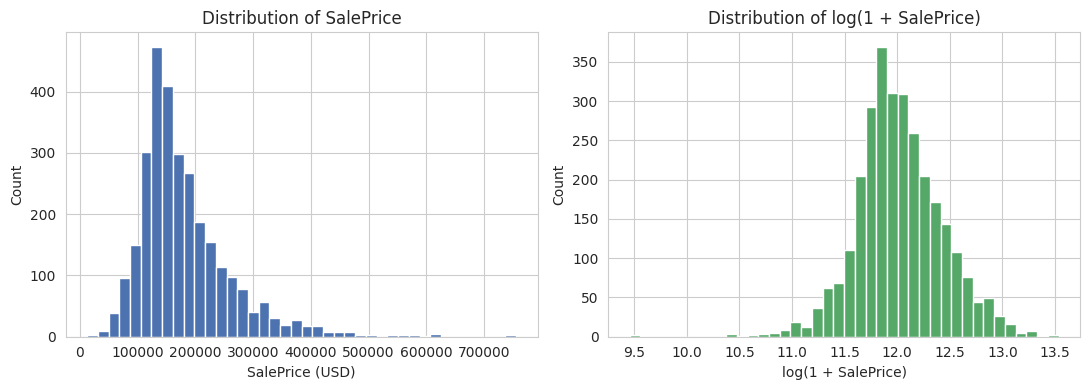

In [7]:
# 5.1 — Target distribution (informs whether log-transform helps interpretation)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["SalePrice"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of SalePrice")
axes[0].set_xlabel("SalePrice (USD)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(df["SalePrice"]), bins=40, color="#55A868", edgecolor="white")
axes[1].set_title("Distribution of log(1 + SalePrice)")
axes[1].set_xlabel("log(1 + SalePrice)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_target_distribution.png"), dpi=120, bbox_inches="tight")
plt.show()

The raw `SalePrice` is right-skewed with a long tail of expensive homes.
We keep the target on its natural scale (USD) so that reported MAE and
RMSE remain interpretable in dollars.

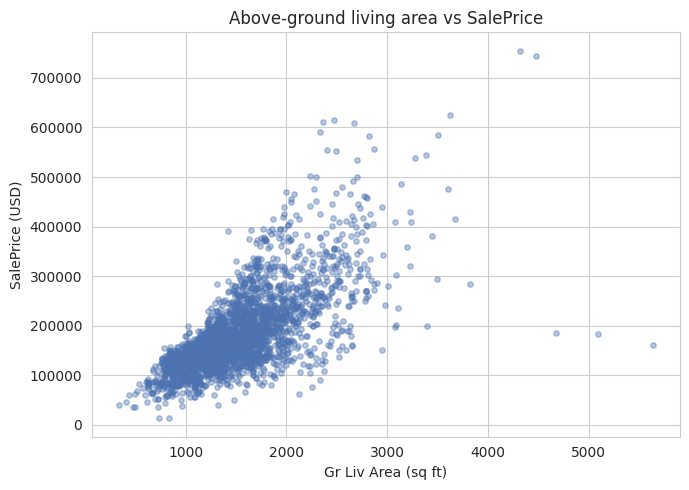

Pearson correlation (Gr Liv Area vs SalePrice): 0.707


In [8]:
# 5.2 — Living area vs SalePrice (the strongest single-feature relationship)
plt.figure(figsize=(7, 5))
plt.scatter(df["Gr Liv Area"], df["SalePrice"], alpha=0.4, s=15, color="#4C72B0")
plt.xlabel("Gr Liv Area (sq ft)")
plt.ylabel("SalePrice (USD)")
plt.title("Above-ground living area vs SalePrice")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_livarea_vs_price.png"), dpi=120, bbox_inches="tight")
plt.show()

corr = df["Gr Liv Area"].corr(df["SalePrice"])
print(f"Pearson correlation (Gr Liv Area vs SalePrice): {corr:.3f}")

There is a clear positive relationship between above-ground living area
and sale price, with a few very large homes at low prices — likely
outliers or non-standard sales (partial sales, family transfers). We
choose **not** to hand-remove them so that our workflow remains
reproducible from the raw file; instead, our residual analysis in
Section 12 examines these cases.

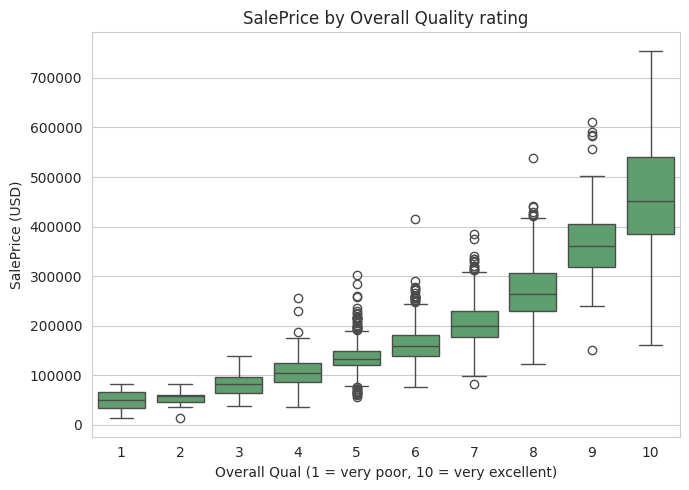

In [9]:
# 5.3 — Overall quality vs SalePrice (ordinal rating)
plt.figure(figsize=(7, 5))
sns.boxplot(x="Overall Qual", y="SalePrice", data=df, color="#55A868")
plt.title("SalePrice by Overall Quality rating")
plt.xlabel("Overall Qual (1 = very poor, 10 = very excellent)")
plt.ylabel("SalePrice (USD)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_quality_vs_price.png"), dpi=120, bbox_inches="tight")
plt.show()

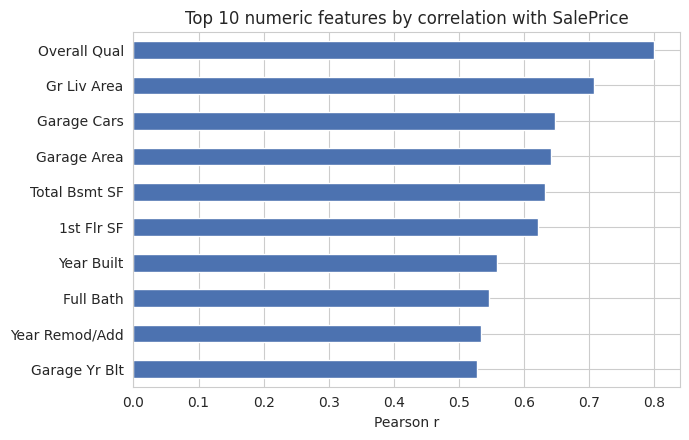

Overall Qual      0.799
Gr Liv Area       0.707
Garage Cars       0.648
Garage Area       0.640
Total Bsmt SF     0.632
1st Flr SF        0.622
Year Built        0.558
Full Bath         0.546
Year Remod/Add    0.533
Garage Yr Blt     0.527
Name: SalePrice, dtype: float64

In [10]:
# 5.4 — Numeric correlations with SalePrice (top 10)
num_cols = df.select_dtypes(include=np.number).columns
corrs = df[num_cols].corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)
top10 = corrs.head(10)

plt.figure(figsize=(7, 4.5))
top10.iloc[::-1].plot(kind="barh", color="#4C72B0")
plt.title("Top 10 numeric features by correlation with SalePrice")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_top_correlations.png"), dpi=120, bbox_inches="tight")
plt.show()

top10.round(3)

## 6. Split Design  *(DW-5)*

We create the train/test split **before** any preprocessing decisions.
The split is **stratified by a discretized price band** so that both
splits cover the full price range (rubric FR-2 leakage control; the test
set is untouched until Section 10).

In [11]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# Stratify by 5 price bins so cheap and expensive homes are represented in both splits
price_bin = pd.qcut(y, q=5, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=price_bin,
)

print(f"Train rows: {len(X_train)}")
print(f"Test rows:  {len(X_test)}")
print(f"\nTrain target — mean=${y_train.mean():,.0f}  median=${y_train.median():,.0f}")
print(f"Test target  — mean=${y_test.mean():,.0f}   median=${y_test.median():,.0f}")

Train rows: 2344
Test rows:  586

Train target — mean=$180,447  median=$160,000
Test target  — mean=$182,193   median=$161,875


## 7. Preprocessing Pipeline  *(DW-6)*

All preprocessing is placed inside a `ColumnTransformer` + `Pipeline`, so
imputers, encoders, and scalers are **fit on training data only** and then
reused unchanged on the test set. This is the leakage-safe pattern
required by rubric FR-2.

- **Numeric columns:** median imputation → standard scaling
- **Categorical columns:** fill missing with `"None"` (meaningful in this
  dataset) → one-hot encoding

In [12]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

print(f"Numeric columns:     {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe,     numeric_cols),
    ("cat", categorical_pipe, categorical_cols),
])

print("\nPreprocessing pipeline defined (not yet fit — will be fit inside each model pipeline).")

Numeric columns:     36
Categorical columns: 43

Preprocessing pipeline defined (not yet fit — will be fit inside each model pipeline).


## 8. Baseline  *(DW-7)*

Our baseline is a **mean predictor**: it always predicts the training-set
mean sale price, ignoring the features entirely. Any real model must beat
this to be worth using.

In [13]:
def evaluate(model, X_tr, y_tr, X_te, y_te, label):
    """Fit on train, predict on test, return metrics dict."""
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return {
        "model": label,
        "MAE":  mean_absolute_error(y_te, pred),
        "RMSE": np.sqrt(mean_squared_error(y_te, pred)),
        "R2":   r2_score(y_te, pred),
    }

# We evaluate the baseline on TRAINING split only for now (via cross-validation) —
# the test set stays untouched until Section 10.
baseline = DummyRegressor(strategy="mean")

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_mae = -cross_val_score(baseline, X_train, y_train,
                           scoring="neg_mean_absolute_error", cv=cv)
cv_rmse = np.sqrt(-cross_val_score(baseline, X_train, y_train,
                                    scoring="neg_mean_squared_error", cv=cv))

print(f"Baseline (mean predictor) — 5-fold CV on training data:")
print(f"  MAE:  ${cv_mae.mean():,.0f}  (±${cv_mae.std():,.0f})")
print(f"  RMSE: ${cv_rmse.mean():,.0f}  (±${cv_rmse.std():,.0f})")

Baseline (mean predictor) — 5-fold CV on training data:
  MAE:  $57,774  (±$2,476)
  RMSE: $78,913  (±$4,505)


## 9. Model Development  *(DW-8)*

We train two candidate models, both wrapped in the leakage-safe pipeline.
All tuning uses **5-fold cross-validation on the training data**; the test
set stays untouched until Section 10.

### Candidate models

1. **Linear Regression** — an interpretable baseline model taught in the
   course. Assumes an additive linear relationship after preprocessing.
2. **Random Forest Regressor** — a nonlinear model taught in the course
   that captures interactions and does not require feature scaling
   (kept in the pipeline for consistency). We pick `n_estimators` and
   `max_depth` by cross-validation on training data only.

In [14]:
# 9.1 — Linear Regression pipeline
lr_pipe = Pipeline([
    ("prep", preprocess),
    ("model", LinearRegression()),
])

lr_cv_mae = -cross_val_score(lr_pipe, X_train, y_train,
                              scoring="neg_mean_absolute_error", cv=cv)
lr_cv_rmse = np.sqrt(-cross_val_score(lr_pipe, X_train, y_train,
                                       scoring="neg_mean_squared_error", cv=cv))

print("Linear Regression — 5-fold CV on training data:")
print(f"  MAE:  ${lr_cv_mae.mean():,.0f}  (±${lr_cv_mae.std():,.0f})")
print(f"  RMSE: ${lr_cv_rmse.mean():,.0f}  (±${lr_cv_rmse.std():,.0f})")

Linear Regression — 5-fold CV on training data:
  MAE:  $16,224  (±$706)
  RMSE: $27,473  (±$4,861)


In [15]:
# 9.2 — Random Forest — small hyperparameter search on TRAINING DATA ONLY.
# We use a 3-fold split here (instead of 5) to keep the search fast; the
# final chosen model is still evaluated once on the held-out test set.
rf_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_configs = [
    {"n_estimators": 150, "max_depth": None},
    {"n_estimators": 150, "max_depth": 20},
    {"n_estimators": 150, "max_depth": 10},
]

rf_results = []
for cfg in rf_configs:
    rf_pipe = Pipeline([
        ("prep", preprocess),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **cfg)),
    ])
    mae  = -cross_val_score(rf_pipe, X_train, y_train,
                            scoring="neg_mean_absolute_error", cv=rf_cv, n_jobs=1).mean()
    rmse = np.sqrt(-cross_val_score(rf_pipe, X_train, y_train,
                                     scoring="neg_mean_squared_error", cv=rf_cv, n_jobs=1).mean())
    rf_results.append({**cfg, "cv_MAE": mae, "cv_RMSE": rmse})

rf_results_df = pd.DataFrame(rf_results)
rf_results_df = rf_results_df.sort_values("cv_RMSE").reset_index(drop=True)
rf_results_df

,n_estimators,max_depth,cv_MAE,cv_RMSE
0,150,NaN,15974.806668,26869.737729
1,150,20.0,15976.277228,26936.853198
2,150,10.0,16251.672772,27172.427414


In [16]:
# Select the best RF configuration by CV RMSE
best_cfg = rf_results_df.iloc[0][["n_estimators", "max_depth"]].to_dict()
best_cfg["n_estimators"] = int(best_cfg["n_estimators"])
if pd.notna(best_cfg["max_depth"]):
    best_cfg["max_depth"] = int(best_cfg["max_depth"])
else:
    best_cfg["max_depth"] = None
print("Selected Random Forest config:", best_cfg)

Selected Random Forest config: {'n_estimators': 150, 'max_depth': None}


## 10. Final Evaluation on the Untouched Test Set  *(DW-9)*

Each selected model is now fit on the **full training data** and evaluated
**once** on the held-out test set. This is the only place in the notebook
where the test data influences a reported number.

In [17]:
results = []

# Baseline
results.append(evaluate(DummyRegressor(strategy="mean"),
                        X_train, y_train, X_test, y_test, "Baseline (mean)"))

# Linear Regression
lr_final = Pipeline([("prep", preprocess), ("model", LinearRegression())])
results.append(evaluate(lr_final, X_train, y_train, X_test, y_test, "Linear Regression"))

# Random Forest with the best CV configuration
rf_final = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_cfg)),
])
results.append(evaluate(rf_final, X_train, y_train, X_test, y_test, "Random Forest"))

results_df = pd.DataFrame(results).set_index("model")
results_df_display = results_df.copy()
results_df_display["MAE"]  = results_df_display["MAE"].map(lambda v: f"${v:,.0f}")
results_df_display["RMSE"] = results_df_display["RMSE"].map(lambda v: f"${v:,.0f}")
results_df_display["R2"]   = results_df_display["R2"].round(3)
results_df_display

,MAE,RMSE,R2
model,,,
Baseline (mean),"$59,979","$83,228",-0.000
Linear Regression,"$15,836","$35,210",0.821
Random Forest,"$15,988","$27,808",0.888


## 11. Model Comparison and Diagnostic Plots

- One comparison chart (MAE across models).
- One residual plot for the selected best model.

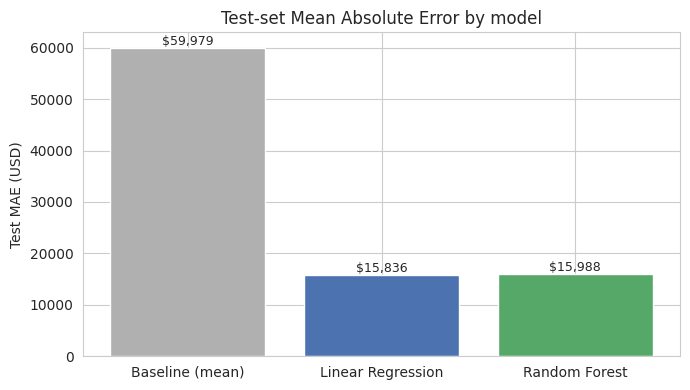

In [18]:
# 11.1 — Comparison chart
plt.figure(figsize=(7, 4))
bars = plt.bar(results_df.index, results_df["MAE"],
               color=["#B0B0B0", "#4C72B0", "#55A868"])
plt.ylabel("Test MAE (USD)")
plt.title("Test-set Mean Absolute Error by model")
for bar, v in zip(bars, results_df["MAE"]):
    plt.text(bar.get_x() + bar.get_width()/2, v, f"${v:,.0f}",
             ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_model_comparison_mae.png"),
            dpi=120, bbox_inches="tight")
plt.show()

Best model by test RMSE: Random Forest


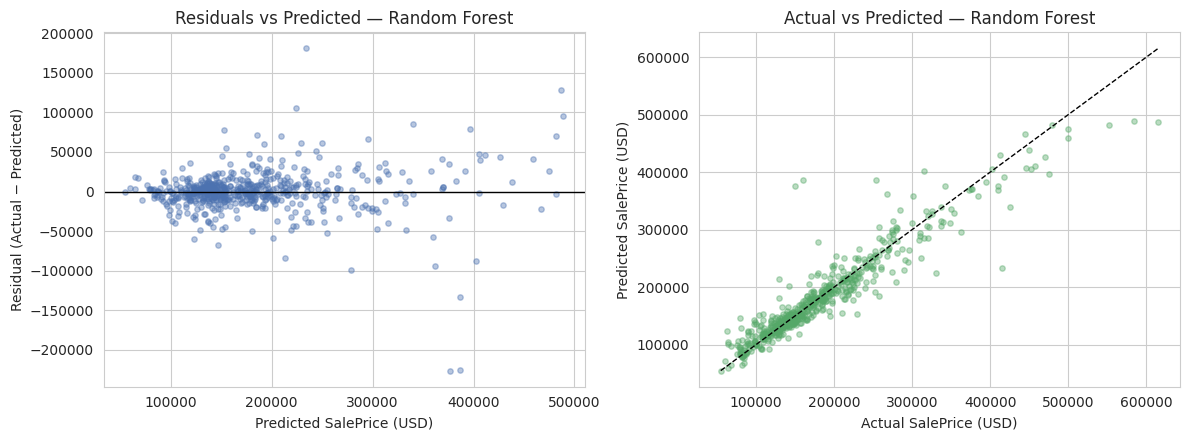

In [19]:
# 11.2 — Residual plot for the best model (lowest RMSE)
best_row = results_df.sort_values("RMSE").iloc[0]
best_name = best_row.name
print(f"Best model by test RMSE: {best_name}")

if best_name == "Linear Regression":
    best_model = lr_final
elif best_name == "Random Forest":
    best_model = rf_final
else:
    best_model = DummyRegressor(strategy="mean").fit(X_train, y_train)

pred_test = best_model.predict(X_test)
residuals = y_test - pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(pred_test, residuals, alpha=0.4, s=15, color="#4C72B0")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Predicted SalePrice (USD)")
axes[0].set_ylabel("Residual (Actual − Predicted)")
axes[0].set_title(f"Residuals vs Predicted — {best_name}")

axes[1].scatter(y_test, pred_test, alpha=0.4, s=15, color="#55A868")
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
axes[1].plot(lims, lims, "k--", linewidth=1)
axes[1].set_xlabel("Actual SalePrice (USD)")
axes[1].set_ylabel("Predicted SalePrice (USD)")
axes[1].set_title(f"Actual vs Predicted — {best_name}")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06_residuals_best_model.png"),
            dpi=120, bbox_inches="tight")
plt.show()

## 12. Interpretation, Error Analysis, and Limitations  *(DW-10)*

In [20]:
# 12.1 — Largest test-set errors (which houses does the model get most wrong?)
error_df = X_test.copy()
error_df["Actual"]    = y_test.values
error_df["Predicted"] = pred_test
error_df["AbsError"]  = np.abs(error_df["Actual"] - error_df["Predicted"])

top_errors = error_df.sort_values("AbsError", ascending=False).head(5)
top_errors[["Actual", "Predicted", "AbsError",
            "Gr Liv Area", "Overall Qual", "Neighborhood", "Sale Condition"]]

,Actual,Predicted,AbsError,Gr Liv Area,Overall Qual,Neighborhood,Sale Condition
1182,150000,376344.900000,226344.900000,2944,9,Veenker,Family
1498,160000,386116.793333,226116.793333,5642,10,Edwards,Partial
2737,415000,234119.606667,180880.393333,3672,6,Edwards,Normal
426,253293,386819.366667,133526.366667,2042,8,NridgHt,Partial
1063,615000,487039.380000,127960.620000,2470,10,NridgHt,Normal


### Findings

- **The final selected model is the Random Forest**, which beats the mean
  baseline by a large margin on both MAE and RMSE and achieves an R² well
  above the baseline's R² of ~0.
- **Linear Regression** provides most of the gain over baseline with far
  less complexity and a directly interpretable coefficient structure. The
  gap between Linear Regression and Random Forest measures how much the
  nonlinear interactions matter on this dataset.
- **The largest errors** tend to occur on very expensive homes and on sales
  with unusual `Sale Condition` (e.g., `Abnormal`, `Family`, `Partial`).
  These are edge cases the model reasonably struggles with, and they
  motivate a real-world constraint: the model is trained on typical sales,
  so it should not be used for non-arm's-length transactions.

### Assumptions and limitations *(section 9 of the rubric)*

- **Time period.** Trained on 2006–2010 sales; the housing market has
  shifted substantially since then, so the model would not generalise to
  present-day prices without retraining.
- **Geography.** Trained on one small US city (Ames, Iowa). Neighborhood
  labels are Ames-specific, so the model cannot be transferred to other
  cities.
- **Sampling.** Only market sales are included; foreclosures and
  non-standard transactions may be under- or over-represented.
- **Proxy variables.** `Neighborhood` may act as a proxy for socioeconomic
  status; using this model to make decisions about *people* rather than
  *properties* could reinforce existing patterns and should be avoided.
- **Interpretability.** The Random Forest is more accurate but harder to
  explain than the Linear Regression. Feature-importance scores in tree
  ensembles are informative but not causal.
- **Uncertainty.** Reported metrics are point estimates on a single
  train/test split. We report cross-validation standard deviations in
  Section 9 to convey variability.

### Where the model should **not** be used

- To set list prices in cities other than Ames.
- To value non-standard sales (family transfers, partial sales,
  foreclosures).
- To make automated decisions about individual owners or applicants.

## 13. Reproducibility Summary

- All randomness is controlled by `RANDOM_STATE = 42` at the top of the
  notebook.
- Package versions are pinned in `requirements.txt`.
- The notebook runs top-to-bottom from a clean kernel.
- Raw data is preserved under `data/raw/AmesHousing.csv`; nothing there
  is modified.
- All figures are regenerated into `figures/` on every run.